In [1]:
import os
import warnings

warnings.filterwarnings("ignore")
# We import all our dependencies.
import numpy as np
import torch
import sys
sys.path.insert(0, "/home/sheida.rahnamai/GIT/HDN/")
from boilerplate import boilerplate
from boilerplate.dataloader import Custom2DDataset
from tqdm import tqdm
import tifffile as tiff
import pickle

In [1]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

patch_size = 64

gaussian_noise_std = None


model_name = "2D_HVAE"
directory_path = "/group/jug/Sheida/HVAE/2D/equidistanced/"
noiseModel = None

# Training-specific
batch_size = 512
lr = 3e-4
max_epochs = 500

# Model-specific
load_checkpoint = False
checkpoint = directory_path + "model/2D_HVAE_best_vae.net"
num_latents = 3
z_dims = [32] * int(num_latents)
blocks_per_layer = 5
batchnorm = True
free_bits = 0.0

alpha = 1
beta = 1e-3
gamma = 1
# contrastive
mask_size = 1
label_size = 1
mode = "1x1"
contrastive_learning = False
margin = 50
lambda_contrastive = 0.5

use_wandb = True

semi_supervised = True
labeled_ratio = 1

stochastic_block_type = "mixture"  # 'normal' or 'mixture'
n_components = 4  # Used only for Mixture block

percent_labeled = "1_percent"

train_labeled_indices = None
val_labeled_indices = None

if semi_supervised:
    labeled_ratio = 0.5
    classes = ["uncategorized", "nucleus", "granule", "mitochondria"]
    train_labeled_indices = []
    val_labeled_indices = []
    for cls in classes:
        with open(
            f"/group/jug/Sheida/pancreatic beta cells/download/2d/train/{mode}/{percent_labeled}_{cls}.pickle",
            "rb",
        ) as file:
            train_labeled_indices.extend(pickle.load(file))
        with open(
            f"/group/jug/Sheida/pancreatic beta cells/download/2d/val/{mode}/{percent_labeled}_{cls}.pickle",
            "rb",
        ) as file:
            val_labeled_indices.extend(pickle.load(file))

# train data

data_dir = "/group/jug/Sheida/pancreatic beta cells/download/2d/"
keys = ["high_c1", "high_c2", "high_c3"]

# Load source images
train_img_paths = [
    os.path.join(data_dir + "train/" + key + f"/{key}_source.tif") for key in keys
]
train_lbl_paths = [
    os.path.join(data_dir + "train/" + key + f"/{key}_gt.tif") for key in keys
]
val_img_paths = [
    os.path.join(data_dir + "val/" + key + f"/{key}_source.tif") for key in keys
]
val_lbl_paths = [
    os.path.join(data_dir + "val/" + key + f"/{key}_gt.tif") for key in keys
]

train_images = {key: tiff.imread(path) for key, path in zip(keys, train_img_paths)}
train_labels = {key: tiff.imread(path) for key, path in zip(keys, train_lbl_paths)}

val_images = {key: tiff.imread(path) for key, path in zip(keys, val_img_paths)}
val_labels = {key: tiff.imread(path) for key, path in zip(keys, val_lbl_paths)}

valid_train = {}
valid_val = {}

for key in tqdm(keys, desc="filtering out outside of the cell"):
    filtered_image, filtered_label, valid_train[key] = boilerplate._filter_slices(
        train_images[key], train_labels[key]
    )
    train_images[key] = filtered_image
    train_labels[key] = filtered_label

    filtered_image, filtered_label, valid_val[key] = boilerplate._filter_slices(
        val_images[key], val_labels[key]
    )

    val_images[key] = filtered_image
    val_labels[key] = filtered_label

# compute mean and std of the data
all_elements = np.concatenate([train_images[key].flatten() for key in keys])
data_mean = np.mean(all_elements)
data_std = np.std(all_elements)

# normalizing the data
for key in tqdm(keys, "Normalizing data"):
    train_images[key] = (train_images[key] - data_mean) / data_std
    val_images[key] = (val_images[key] - data_mean) / data_std
train_set = Custom2DDataset(
    train_images, train_labels, patch_size, mask_size, label_size, train_labeled_indices
)
val_set = Custom2DDataset(
    val_images, val_labels, patch_size, mask_size, label_size, val_labeled_indices
)


Normalizing data: 100%|██████████| 3/3 [00:02<00:00,  1.33it/s]
Extracting patches from high_c1: 965it [00:03, 264.04it/s]
Extracting patches from high_c2: 889it [00:03, 268.06it/s]
Extracting patches from high_c3: 907it [00:03, 264.28it/s]
Extracting patches from high_c1: 109it [00:00, 306.26it/s]
Extracting patches from high_c2: 101it [00:00, 316.71it/s]
Extracting patches from high_c3: 103it [00:00, 284.06it/s]


In [13]:
os.makedirs("output/validation/masked_labels", exist_ok=True)
os.makedirs("output/validation/images", exist_ok=True)

In [15]:
indices = np.array(val_set.indices)[val_labeled_indices]

In [16]:
indices

array([['high_c1', '7', '223', '351'],
       ['high_c1', '50', '415', '287'],
       ['high_c1', '23', '223', '479'],
       ['high_c1', '27', '95', '287'],
       ['high_c2', '40', '351', '543'],
       ['high_c1', '61', '351', '479'],
       ['high_c2', '1', '415', '607'],
       ['high_c1', '50', '543', '415'],
       ['high_c2', '2', '287', '543'],
       ['high_c2', '6', '287', '223'],
       ['high_c1', '71', '95', '607'],
       ['high_c1', '74', '287', '287'],
       ['high_c1', '13', '543', '95'],
       ['high_c2', '35', '479', '95'],
       ['high_c1', '17', '479', '31'],
       ['high_c1', '55', '543', '351'],
       ['high_c1', '80', '543', '287'],
       ['high_c3', '15', '159', '543'],
       ['high_c3', '70', '287', '735'],
       ['high_c3', '71', '95', '223'],
       ['high_c2', '71', '479', '95'],
       ['high_c3', '31', '351', '671'],
       ['high_c1', '98', '95', '351'],
       ['high_c1', '6', '351', '607'],
       ['high_c3', '2', '351', '95'],
       ['high_c

In [17]:
grouped_indices = {}
for element in indices:
    key, z_index, y_index, x_index = element
    z_index, y_index, x_index = map(int, [z_index, y_index, x_index])

    # Group by (key, z_index) and collect (y, x) positions
    grouped_indices.setdefault((key, z_index), []).append((y_index, x_index))

In [18]:
grouped_indices

{('high_c1', 7): [(223, 351)],
 ('high_c1', 50): [(415, 287), (543, 415)],
 ('high_c1', 23): [(223, 479)],
 ('high_c1', 27): [(95, 287), (159, 223)],
 ('high_c2', 40): [(351, 543)],
 ('high_c1', 61): [(351, 479)],
 ('high_c2', 1): [(415, 607), (159, 287)],
 ('high_c2', 2): [(287, 543)],
 ('high_c2', 6): [(287, 223)],
 ('high_c1', 71): [(95, 607), (223, 415)],
 ('high_c1', 74): [(287, 287), (287, 351), (543, 351)],
 ('high_c1', 13): [(543, 95)],
 ('high_c2', 35): [(479, 95)],
 ('high_c1', 17): [(479, 31), (415, 287)],
 ('high_c1', 55): [(543, 351)],
 ('high_c1', 80): [(543, 287)],
 ('high_c3', 15): [(159, 543), (543, 479)],
 ('high_c3', 70): [(287, 735)],
 ('high_c3', 71): [(95, 223), (159, 543), (351, 543)],
 ('high_c2', 71): [(479, 95)],
 ('high_c3', 31): [(351, 671)],
 ('high_c1', 98): [(95, 351), (351, 543)],
 ('high_c1', 6): [(351, 607), (287, 479)],
 ('high_c3', 2): [(351, 95)],
 ('high_c3', 65): [(351, 415)],
 ('high_c3', 33): [(223, 607), (287, 287)],
 ('high_c2', 77): [(287, 47

In [19]:
# Iterate over each unique (key, z_index) pair and create masked labels
for (key, z_index), yx_indices in grouped_indices.items():
    # Retrieve the full label and image slice
    label_slice = val_labels[key][z_index].copy()
    image_slice = val_images[key][z_index].copy()
    
    # Initialize the masked label slice with -1
    masked_label_slice = np.full_like(label_slice, -1)
    
    # Set only the specified (y, x) indices to their actual values in the label slice
    for y, x in yx_indices:
        masked_label_slice[y, x] = label_slice[y, x]
    
    # Define filenames for TIFF saving
    label_filename = f"output/validation/masked_labels/{key}_{z_index}.tiff"
    image_filename = f"output/validation/images/{key}_{z_index}.tiff"
    
    # Save the image and masked label as TIFF files
    tiff.imwrite(image_filename, image_slice)
    tiff.imwrite(label_filename, masked_label_slice)

print("Images and masked labels saved successfully as TIFF files.")

Images and masked labels saved successfully as TIFF files.


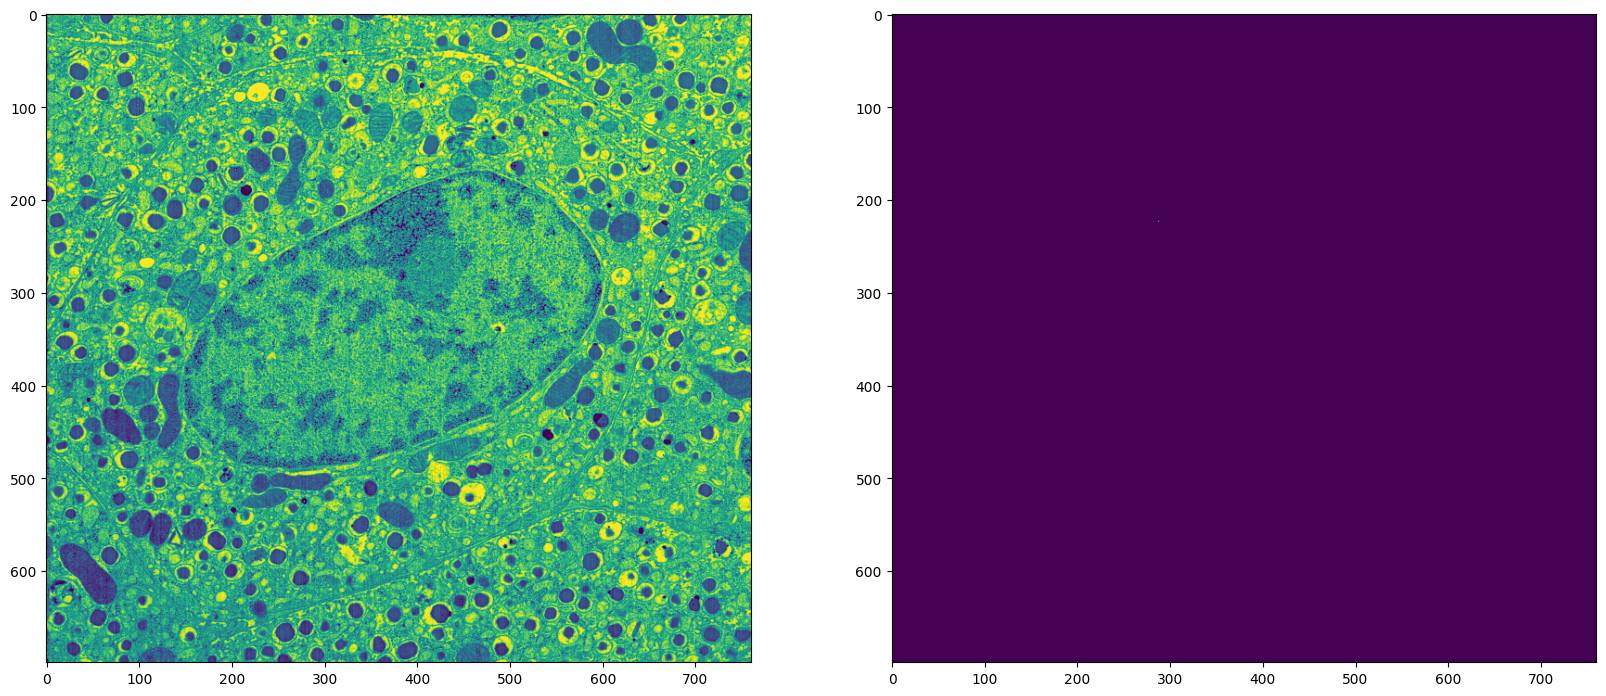

In [21]:
from matplotlib import pyplot as plt
img = tiff.imread("output/validation/images/high_c1_35.tiff")
lbl = tiff.imread("output/validation/masked_labels/high_c1_35.tiff")
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img)
ax[1].imshow(lbl)
plt.show()

In [22]:
for x in lbl.flatten():
    if x != -1:
        print(x)

0
